In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_moons
x, y=make_moons(n_samples=500, noise=0.30, random_state=2)

In [3]:
def plot_dataset(x, y, axes):
    plt.plot(x[y==0,0],x[y==0,1],'ro',markersize=3)
    plt.plot(x[y==1,0],x[y==1,1],'g^',markersize=3)
    plt.axis(axes)
    plt.grid(True, which='both')
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.ylabel(r"$x_2$", fontsize=18)

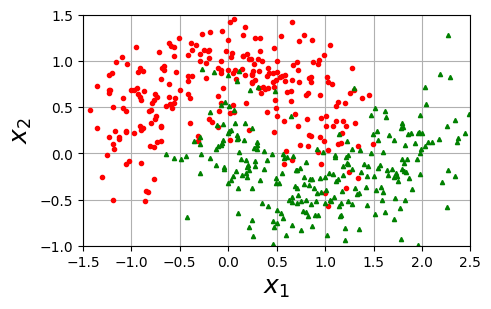

In [4]:
plt.figure(figsize=(5,3))
plot_dataset(x,y,[-1.5,2.5,-1,1.5])
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x, y, random_state=1)

In [6]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf=RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, oob_score=True,random_state=1)
rnd_clf.fit(x_train, y_train)
rnd_clf.score(x_train,y_train)

0.9573333333333334

In [7]:
rnd_clf.oob_score_

0.9093333333333333

In [8]:
rnd_clf.score(x_test,y_test)

0.88

In [9]:
rnd_clf.feature_importances_

array([0.38183967, 0.61816033])

In [10]:
def plot_decision_boundary(clf, x, y, axes=[-1.5,2.45,-1,1.5]):
    x1s=np.linspace(axes[0], axes[1], 100)
    x2s=np.linspace(axes[2], axes[3], 100)
    x1, x2=np.meshgrid(x1s, x2s)
    x_new=np.c_[x1.ravel(), x2.ravel()]
    y_pred=clf.predict(x_new).reshape(x1.shape)
    plt.contourf(x1, x2, y_pred, alpha=0.2)
    plt.contour(x1, x2, y_pred)
    plot_dataset(x, y, axes)

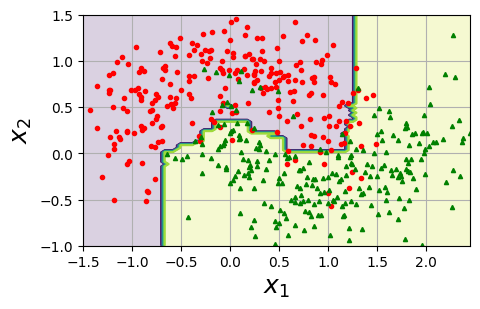

In [11]:
plt.figure(figsize=(5,3))
plot_decision_boundary(rnd_clf, x, y)
plt.show()

In [13]:
from sklearn.ensemble import ExtraTreesClassifier
ext_clf=ExtraTreesClassifier(random_state=1)
ext_clf.fit(x_train, y_train)
ext_clf.score(x_test,y_test)

0.864

In [14]:
ext_clf.feature_importances_

array([0.42425007, 0.57574993])

In [17]:
np.random.seed(1)
m=200
x=np.random.rand(m,1)
y=4*(x[:,0]-0.5)**2+np.random.randn(m)/10

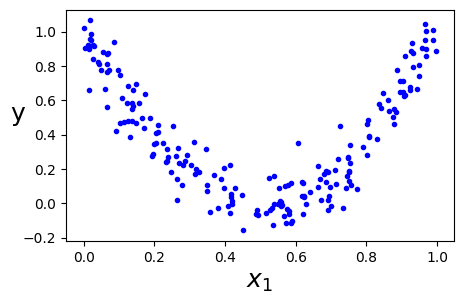

In [18]:
plt.figure(figsize=(5,3))
plt.plot(x,y,'b.')
plt.xlabel('$x_1$', fontsize=18)
plt.ylabel('y', rotation=0, fontsize=18)
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x, y, random_state=1)

In [20]:
from sklearn.ensemble import RandomForestRegressor
rnd_reg=RandomForestRegressor(n_estimators=500,max_leaf_nodes=16,oob_score=True,random_state=1)
rnd_reg.fit(x_train, y_train)
rnd_reg.score(x_train,y_train)

0.9417364410547316

In [21]:
rnd_reg.oob_score_

0.8746177182126228

In [22]:
rnd_reg.score(x_test,y_test)

0.9157119465346966

In [23]:
rnd_reg.feature_importances_

array([1.])

In [25]:
def plot_regression_predictions(tree_reg, x, y, axes=[0,1, -0.2, 1]):
    x1=np.linspace(axes[0], axes[1], 500).reshape(-1,1)
    y_pred=tree_reg.predict(x1)
    plt.plot(x, y, 'b.')
    plt.plot(x1, y_pred, 'r.-', linewidth=2, label=r'$\hat{y}$')
    plt.axis(axes)
    plt.xlabel('$x_1$', fontsize=18)
    plt.ylabel('$y$', rotation=0, fontsize=18)
    plt.legend(loc='upper center', fontsize=14)

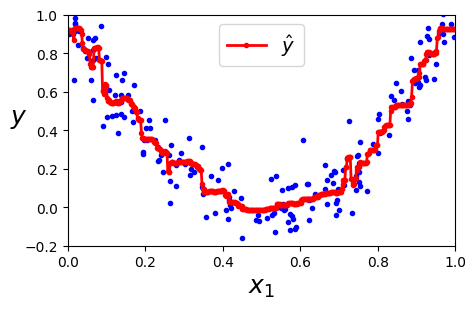

In [26]:
plt.figure(figsize=(5,3))
plot_regression_predictions(rnd_reg, x, y)
plt.show()

In [27]:
from sklearn.ensemble import ExtraTreesRegressor
ext_reg=ExtraTreesRegressor(random_state=1)
ext_reg.fit(x_train, y_train)
ext_reg.score(x_test,y_test)

0.8723823510592347

In [28]:
ext_reg.feature_importances_

array([1.])